In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv("loan_train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [ ]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Married'] = df['Married'].map({'Yes':1, 'No':0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':0, 'N':1})  # 1 = Default

In [ ]:
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

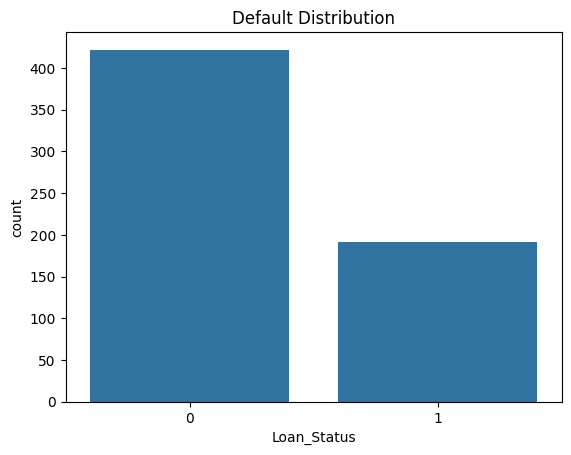

In [ ]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Default Distribution")
plt.show()

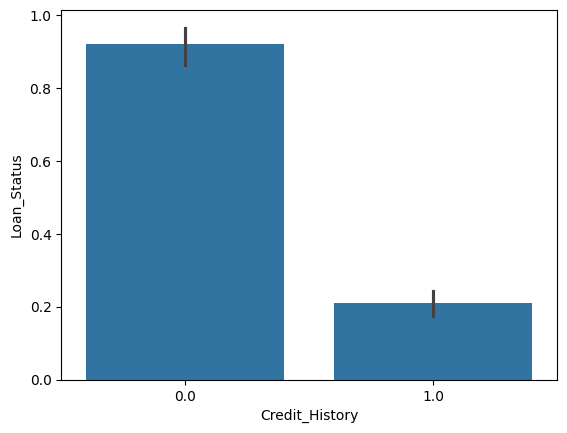

In [ ]:
sns.barplot(x='Credit_History', y='Loan_Status', data=df)
plt.show()


In [ ]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Loan_to_Income'] = df['LoanAmount'] / df['Total_Income']

In [ ]:
df.drop('Loan_ID', axis=1, inplace=True)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

In [ ]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [ ]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))
print(confusion_matrix(y_test, rf.predict(X_test)))

RF Accuracy: 0.7723577235772358
[[75 10]
 [18 20]]


In [ ]:
test_df = pd.read_csv("loan_test.csv")
test_df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [ ]:
loan_ids = test_df['Loan_ID']

In [ ]:
test_df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
test_df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
test_df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

In [ ]:
test_df['Gender'] = test_df['Gender'].map({'Male':1, 'Female':0})
test_df['Married'] = test_df['Married'].map({'Yes':1, 'No':0})
test_df['Education'] = test_df['Education'].map({'Graduate':1, 'Not Graduate':0})
test_df['Self_Employed'] = test_df['Self_Employed'].map({'Yes':1, 'No':0})

In [ ]:
test_df = pd.get_dummies(test_df, columns=['Property_Area'], drop_first=True)

In [ ]:
test_df['Total_Income'] = test_df['ApplicantIncome'] + test_df['CoapplicantIncome']
test_df['Loan_to_Income'] = test_df['LoanAmount'] / test_df['Total_Income']
test_df['Income_Bucket'] = pd.cut(
    test_df['Total_Income'],
    bins=[0,2500,5000,10000,100000],
    labels=[0,1,2,3]
)

In [ ]:
test_df.drop(['Loan_ID'], axis=1, inplace=True)

In [ ]:
test_df = test_df.reindex(columns=X.columns, fill_value=0)

In [ ]:
test_df['Dependents'].fillna(test_df['Dependents'].mode()[0], inplace=True)
test_df['Dependents'] = test_df['Dependents'].replace('3+', 3)
test_df['Dependents'] = test_df['Dependents'].astype(int)
test_scaled = scaler.transform(test_df)

In [ ]:
test_scaled = scaler.transform(test_df)

In [ ]:
test_predictions = rf.predict(test_scaled)

In [ ]:
prediction_labels = ['Default' if x == 1 else 'Non-Default' for x in test_predictions]

In [ ]:
final_output = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Loan_Status_Prediction': prediction_labels
})

final_output.head()

,Loan_ID,Loan_Status_Prediction
0,LP001015,Non-Default
1,LP001022,Non-Default
2,LP001031,Non-Default
3,LP001035,Non-Default
4,LP001051,Non-Default


In [ ]:
final_output.to_csv("loan_default_predictions.csv", index=False)